# Complex Networks Assigmnent 2: Community detection

Maria Guasch Torres: maria.guasch.t@estudiantat.upc.edu

Andreu Garcies Ramon: andreu.garcies@estudiantat.upc.edu

In [1]:
import os
from utils import *
from tqdm import tqdm
from synthetic import *
import matplotlib.pyplot as plt
from primary_school import *

plt.rcParams.update({
    "text.usetex": True
})

## 1. Characterization of the community structure of networks with block structure.

In [2]:
DATA_PATH = "data"
SYNTHETIC_NETWORKS = "synthetic"
ASSETS = "assets"
os.makedirs(ASSETS, exist_ok=True)
INITIAL_NETWORK_VISUALIZATIONS = os.path.join(ASSETS, "initial_network_visualizations")
os.makedirs(INITIAL_NETWORK_VISUALIZATIONS, exist_ok=True)

DEGREE_DISTRIBUTION_PLOTS = os.path.join(ASSETS, "degree_distribution_plots")
os.makedirs(DEGREE_DISTRIBUTION_PLOTS, exist_ok=True)

GREEDY_COMMUNITY_VISUALIZATIONS = os.path.join(ASSETS, "greedy_community_visualizations")
os.makedirs(GREEDY_COMMUNITY_VISUALIZATIONS, exist_ok=True)

LOUVAIN_COMMUNITY_VISUALIZATIONS = os.path.join(ASSETS, "louvain_community_visualizations")
os.makedirs(LOUVAIN_COMMUNITY_VISUALIZATIONS, exist_ok=True)

INFOMAP_COMMUNITY_VISUALIZATIONS = os.path.join(ASSETS, "infomap_community_visualizations")
os.makedirs(INFOMAP_COMMUNITY_VISUALIZATIONS, exist_ok=True)


COMMUNITIES_OUTPUT = "communities"
os.makedirs(COMMUNITIES_OUTPUT, exist_ok=True)


In [3]:
custom_cmap = generate_colormap()

synth_net_path = os.path.join(DATA_PATH, SYNTHETIC_NETWORKS)

file = sorted(os.listdir(synth_net_path))[-1]
filename = os.path.splitext(file)[0] # Remove the filename extension
print(f"Calculating reference layout using: {file}")
G_ref = nx.read_pajek(os.path.join(synth_net_path, file))
reference_pos = nx.spring_layout(G_ref, seed=42)



files = sorted(os.listdir(synth_net_path))
max_communities = 0

num_communities = {}
modularity_values = {}
jaccard = {}
normalized_mutual_info_values = {}
normalized_variation_of_information = {}

Calculating reference layout using: synthetic_network_N_300_blocks_5_prr_1.00_prs_0.02.net


### 1.1. Comparison of layouts for prr = 0.02.

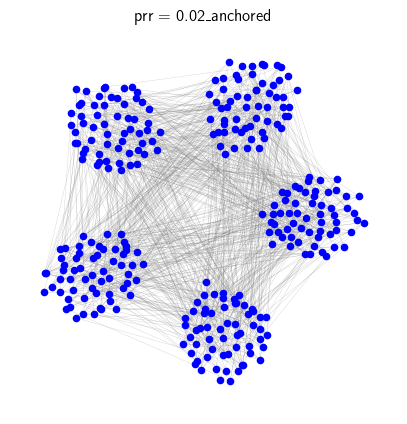

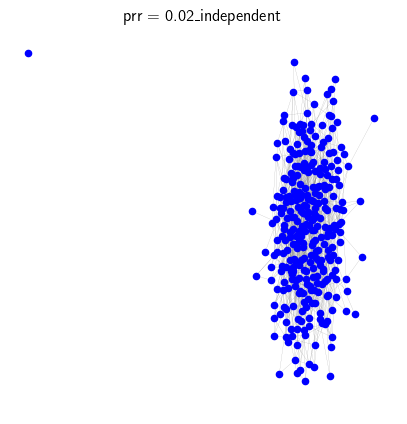

In [4]:
filename = os.path.splitext(files[1])[0]
file_info = extract_filename_info(filename)
prr_value = file_info.get('prr', None)

G = nx.read_pajek(os.path.join(synth_net_path, files[1]))

visualize_network(
    G, pos=reference_pos,
    out_path=INITIAL_NETWORK_VISUALIZATIONS,
    savefig=True,
    show_fig=True,
    prr=f"{prr_value}_anchored"
)

independent_pos = nx.spring_layout(G, seed=42)
visualize_network(
    G, pos=independent_pos,
    out_path=INITIAL_NETWORK_VISUALIZATIONS,
    savefig=True,
    show_fig=True,
    prr=f"{prr_value}_independent"
)

### 1.2. Visualization of all networks and their degree distributions for different values of prr.

In [5]:
# for file in tqdm(files, desc="Processing synthetic networks", total=len(files)):
#     filename = os.path.splitext(file)[0]
#     file_info = extract_filename_info(filename)
#     prr_value = file_info.get('prr', None)
#     n_blocks = int(file_info.get('blocks', 5))
#     G = nx.read_pajek(os.path.join(synth_net_path, file))

    
#     visualize_network(
#         G, pos=reference_pos,
#         out_path=INITIAL_NETWORK_VISUALIZATIONS,
#         savefig=True,
#         show_fig=False,
#         prr=prr_value
#     )
    
#     plot_degree_distributions(
#         G,
#         filepath=file,
#         out_path=DEGREE_DISTRIBUTION_PLOTS,
#         savefig=True,
#         show_fig=False,
#         prr=prr_value,
#     )

### 1.3. Community detection and computation of metrics for different values of prr.

In [6]:
for file in tqdm(files, desc="Processing synthetic networks", total=len(files)):
    filename = os.path.splitext(file)[0]
    file_info = extract_filename_info(filename)
    prr_value = file_info.get('prr', None)
    n_blocks = int(file_info.get('blocks', 5))
    G = nx.read_pajek(os.path.join(synth_net_path, file))

    
    communities_greedy = detect_communities(G, algorithm_name="greedy")
    communities_louvain = detect_communities(G, algorithm_name="louvain")
    communities_infomap = detect_communities(G, algorithm_name="infomap")
    base_name = f"prr_{prr_value}"

    save_partition_to_clu(G, communities_greedy, os.path.join(COMMUNITIES_OUTPUT, f"{base_name}_greedy.clu"))
    save_partition_to_clu(G,communities_louvain, os.path.join(COMMUNITIES_OUTPUT, f"{base_name}_louvain.clu"))
    save_partition_to_clu(G, communities_infomap, os.path.join(COMMUNITIES_OUTPUT, f"{base_name}_infomap.clu"))

    node_list = list(G.nodes())
    true_partition = get_synthetic_ground_truth_partition(node_list, n_blocks=n_blocks)
    labels_true = partition_to_labels(node_list, true_partition)
    labels_greedy = partition_to_labels(node_list, communities_greedy)
    labels_louvain = partition_to_labels(node_list, communities_louvain)
    labels_infomap = partition_to_labels(node_list, communities_infomap)

    num_comms_greedy, mod_greedy = community_metrics(G, communities_greedy)
    num_comms_louvain, mod_louvain = community_metrics(G, communities_louvain)
    num_comms_infomap, mod_infomap = community_metrics(G, communities_infomap)
    
    num_communities[prr_value] = {
        "greedy": num_comms_greedy,
        "louvain": num_comms_louvain,
        "infomap": num_comms_infomap
    }
    modularity_values[prr_value] = {
        "greedy": mod_greedy,
        "louvain": mod_louvain,
        "infomap": mod_infomap
    }

    jaccard[prr_value] = {
        "greedy": partition_jaccard_index(labels_true, labels_greedy),
        "louvain": partition_jaccard_index(labels_true, labels_louvain),
        "infomap": partition_jaccard_index(labels_true, labels_infomap),
    }
    normalized_mutual_info_values[prr_value] = {
        "greedy": partition_normalized_mutual_information(true_partition, communities_greedy),
        "louvain": partition_normalized_mutual_information(true_partition, communities_louvain),
        "infomap": partition_normalized_mutual_information(true_partition, communities_infomap),
    }
    normalized_variation_of_information[prr_value] = {
        "greedy": partition_normalized_variation_of_information(true_partition, communities_greedy, len(node_list)),
        "louvain": partition_normalized_variation_of_information(true_partition, communities_louvain, len(node_list)),
        "infomap": partition_normalized_variation_of_information(true_partition, communities_infomap, len(node_list)),
    }

Processing synthetic networks: 100%|██████████| 51/51 [00:16<00:00,  3.08it/s]


In [7]:
for file in tqdm(files, desc="Processing synthetic networks", total=len(files)):
    filename = os.path.splitext(file)[0]
    file_info = extract_filename_info(filename)
    prr_value = file_info.get('prr', None)
    n_blocks = int(file_info.get('blocks', 5))
    G = nx.read_pajek(os.path.join(synth_net_path, file))

    
    
    communities_greedy = load_partition_from_clu(G, os.path.join(COMMUNITIES_OUTPUT, f"prr_{prr_value}_greedy.clu"))
    communities_louvain = load_partition_from_clu(G, os.path.join(COMMUNITIES_OUTPUT, f"prr_{prr_value}_louvain.clu"))
    communities_infomap = load_partition_from_clu(G, os.path.join(COMMUNITIES_OUTPUT, f"prr_{prr_value}_infomap.clu"))

    # Align community indices across algorithms for better visual comparison
    communities_louvain = reorder_communities(communities_greedy, communities_louvain)
    communities_infomap = reorder_communities(communities_greedy, communities_infomap)
    
    # visualize_network(
    #     G, pos=reference_pos,
    #     out_path=GREEDY_COMMUNITY_VISUALIZATIONS,
    #     savefig=True,
    #     show_fig=False,
    #     prr=prr_value,
    #     communities=communities_greedy
    # )
    # visualize_network(
    #     G, pos=reference_pos,
    #     out_path=LOUVAIN_COMMUNITY_VISUALIZATIONS,
    #     savefig=True,
    #     show_fig=False,
    #     prr=prr_value,
    #     communities=communities_louvain
    # )
    
    # visualize_network(
    #     G, pos=reference_pos,
    #     out_path=INFOMAP_COMMUNITY_VISUALIZATIONS,
    #     savefig=True,
    #     show_fig=False,
    #     prr=prr_value,
    #     communities=communities_infomap
    # )

Processing synthetic networks: 100%|██████████| 51/51 [00:01<00:00, 32.11it/s]


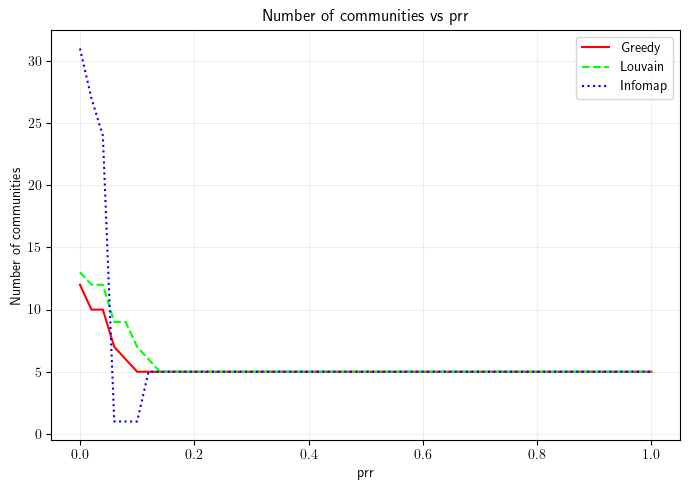

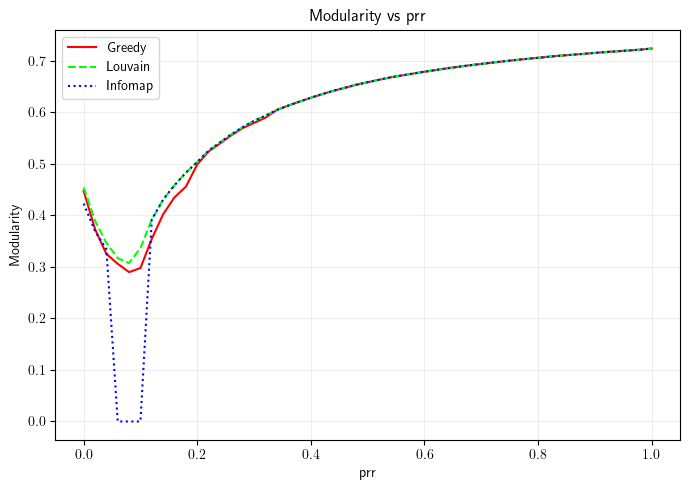

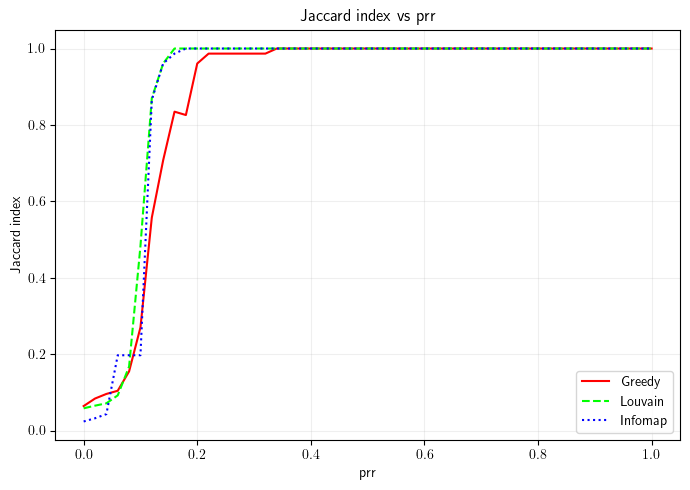

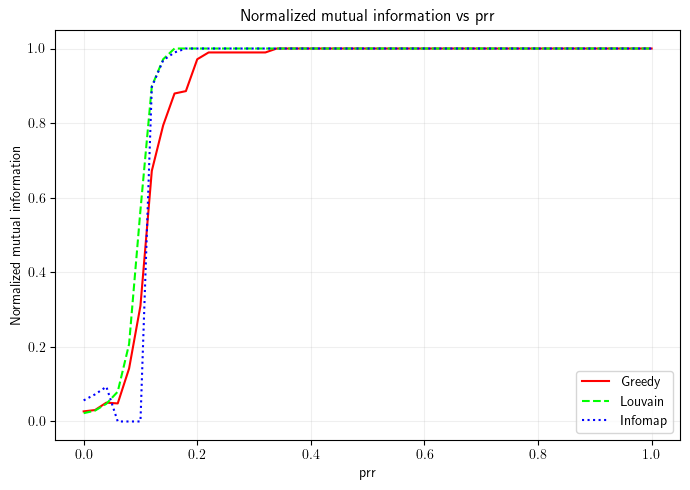

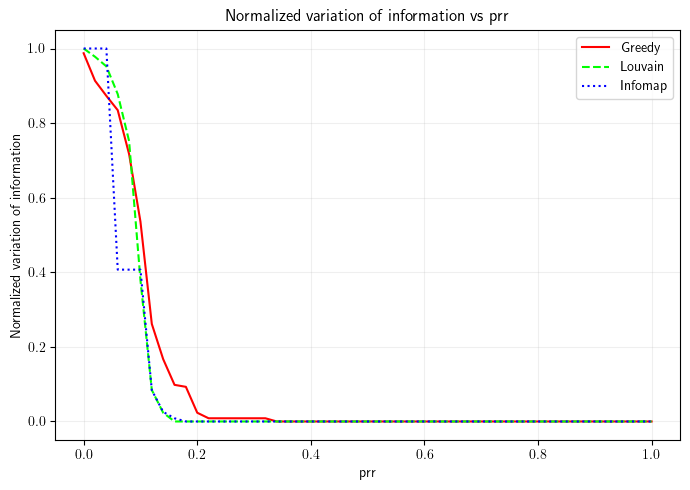

In [8]:
plot_metrics_evolution(num_communities, show_fig=True, savefig=True, out_path=ASSETS, metric_name="Number of communities")
plot_metrics_evolution(modularity_values, show_fig=True, savefig=True, out_path=ASSETS, metric_name="Modularity")
plot_metrics_evolution(jaccard, show_fig=True, savefig=True, out_path=ASSETS, metric_name="Jaccard index")
plot_metrics_evolution(normalized_mutual_info_values, show_fig=True, savefig=True, out_path=ASSETS, metric_name="Normalized mutual information")
plot_metrics_evolution(normalized_variation_of_information, show_fig=True, savefig=True, out_path=ASSETS, metric_name="Normalized variation of information")

## 2. Characterization of the community structure of real networks

In [9]:
PRIMARY_SCHOOL_NETWORKS = "primary_school"
PRIMARY_SCHOOL_WEIGHTED = "primaryschool_w.net"
PRIMARY_SCHOOL_UNWEIGHTED = "primaryschool_u.net"
METADATA = "metadata_primary_school.txt"

In [ ]:
weighted_path = os.path.join(DATA_PATH, PRIMARY_SCHOOL_NETWORKS, PRIMARY_SCHOOL_WEIGHTED)
unweighted_path = os.path.join(DATA_PATH, PRIMARY_SCHOOL_NETWORKS, PRIMARY_SCHOOL_UNWEIGHTED)

Gw = nx.read_pajek(weighted_path)
Gu = nx.read_pajek(unweighted_path)

print(f"Number of nodes in the graph: {Gw.number_of_nodes()}")
print(f"Number of edges in the graph: {Gw.number_of_edges()}")


metadata = load_metadata(DATA_PATH, PRIMARY_SCHOOL_NETWORKS, METADATA)

# Ensure simple graphs
if Gw.is_multigraph():
    Gw = nx.Graph(Gw)
if Gu.is_multigraph():
    Gu = nx.Graph(Gu)


for u, v, d in Gw.edges(data=True):
    w = d["weight"]
    d["inv_weight"] = 1.0 / w if w > 0 else 1.0

pos = nx.kamada_kawai_layout(Gw, weight="inv_weight")

Number of nodes in the graph: 242
Number of edges in the graph: 8317


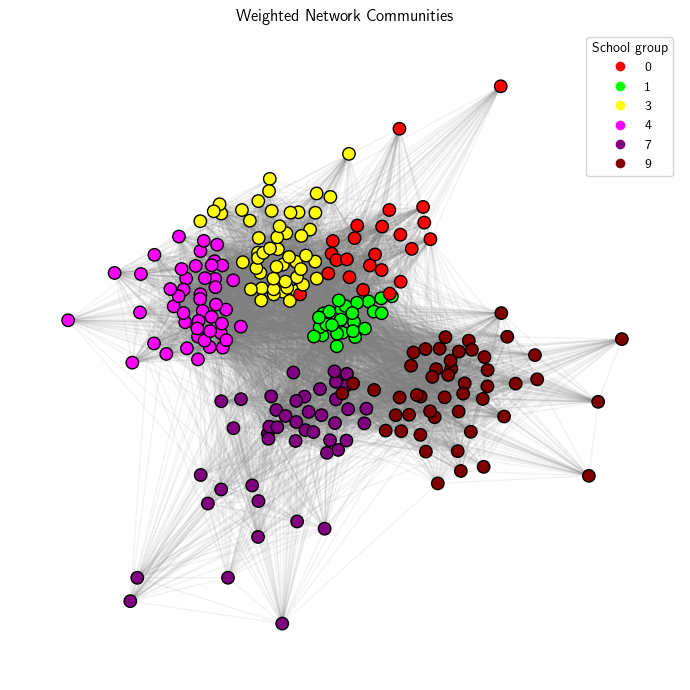

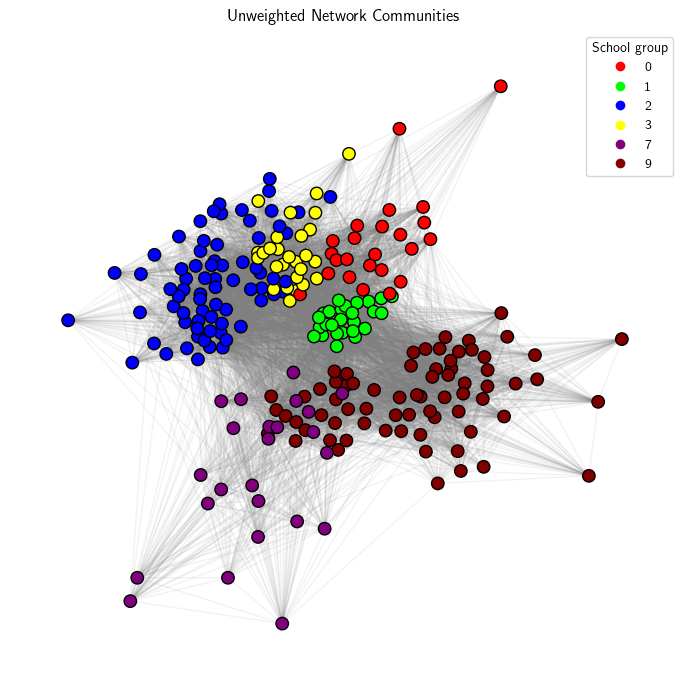

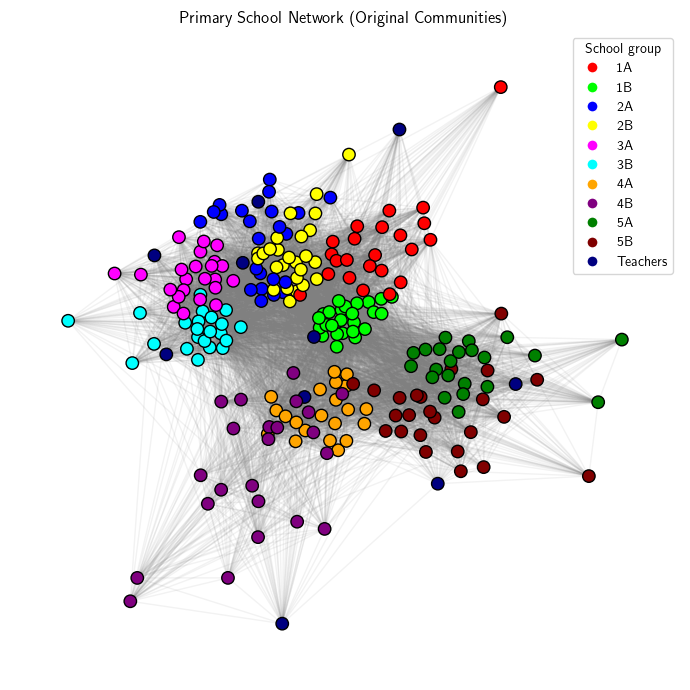

In [11]:
node_to_comm_w, comms_w = detect_communities_primary(Gw, use_weights=True)
node_to_comm_u, comms_u = detect_communities_primary(Gu, use_weights=False)

node_to_group, gt_comms, gt_group_to_color, gt_idx_to_color = ground_truth_communities_and_colors(Gw, metadata)

w_to_gt = best_match_mapping(gt_comms, comms_w)
u_to_gt = best_match_mapping(gt_comms, comms_u)

node_to_comm_w_aligned = {node: w_to_gt.get(comm, comm) for node, comm in node_to_comm_w.items()}
node_to_comm_u_aligned = {node: u_to_gt.get(comm, comm) for node, comm in node_to_comm_u.items()}

draw_communities(Gw, pos, node_to_comm_w_aligned, "Weighted Network Communities", ASSETS, group_to_color=gt_idx_to_color, show_fig=True)
draw_communities(Gu, pos, node_to_comm_u_aligned, "Unweighted Network Communities", ASSETS, group_to_color=gt_idx_to_color, show_fig=True)
draw_communities(Gw, pos, node_to_group, "Primary School Network (Original Communities)", ASSETS, group_to_color=gt_group_to_color, show_fig=True)

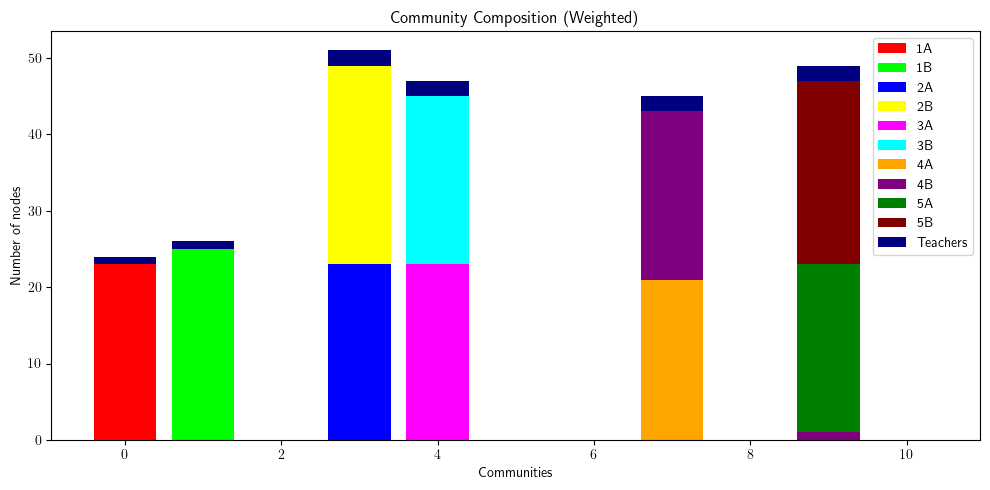

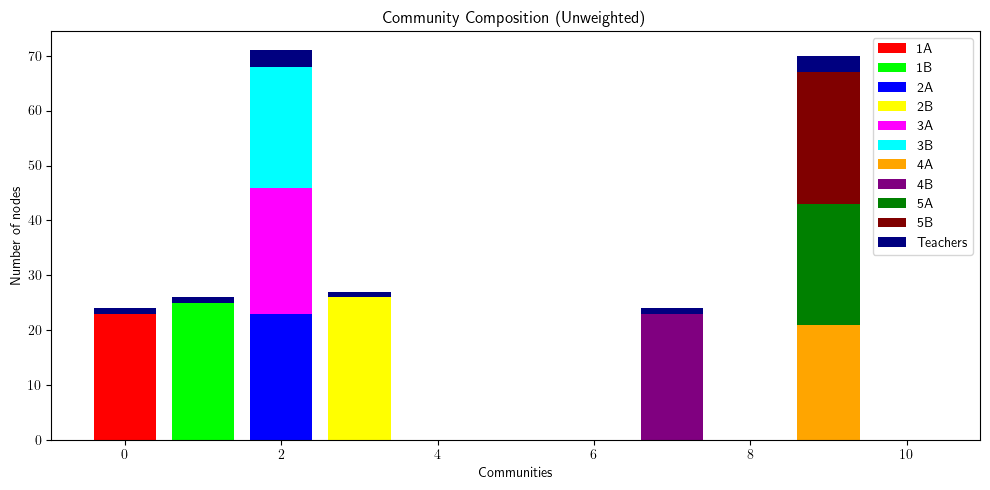

In [12]:
n_gt = len(gt_comms)
comms_w_aligned_for_comp = align_and_pad_communities(gt_comms, comms_w, mapping=w_to_gt, n_communities=n_gt)
comms_u_aligned_for_comp = align_and_pad_communities(gt_comms, comms_u, mapping=u_to_gt, n_communities=n_gt)

comp_w = community_composition(comms_w_aligned_for_comp, metadata)
comp_u = community_composition(comms_u_aligned_for_comp, metadata)

plot_composition(comp_w, "Community Composition (Weighted)", ASSETS)
plot_composition(comp_u, "Community Composition (Unweighted)", ASSETS)